# SmartCare Option C - Preprocessing, Feature Engineering and Model Development

This notebook continues the verified dataset-understanding stage. It compares clinical-only and context-augmented feature sets while keeping the final 20% test set untouched until model selection and tuning are complete.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
    balanced_accuracy_score, classification_report, cohen_kappa_score,
    confusion_matrix, f1_score, mean_absolute_error, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
CLASS_NAMES = ["Low", "Medium", "High"]
CLASS_TO_INT = {name: index for index, name in enumerate(CLASS_NAMES)}
INT_TO_CLASS = {index: name for name, index in CLASS_TO_INT.items()}

## 1. Load data and establish the prediction target

In [2]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "smartcare_ai_dataset_1000.csv"
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
TARGET = "disease_risk_level"

assert set(df[TARGET].unique()) == set(CLASS_NAMES)
assert df[TARGET].isna().sum() == 0

y = df[TARGET].map(CLASS_TO_INT).astype(int)
print(f"Loaded {len(df):,} records and {df.shape[1]} columns")
display(pd.DataFrame({"count": df[TARGET].value_counts().reindex(CLASS_NAMES),
                      "percentage": (df[TARGET].value_counts(normalize=True).reindex(CLASS_NAMES) * 100).round(1)}))

Loaded 1,000 records and 33 columns


,count,percentage
disease_risk_level,,
Low,131,13.1
Medium,469,46.9
High,400,40.0


## 2. Leakage-safe feature sets

The primary model uses information plausibly available at initial assessment. The context experiment adds diagnosis, department and patient-history variables. Post-admission, treatment, billing, payment and other target variables remain excluded.

In [3]:
def add_engineered_features(data):
    """Create deterministic, clinically interpretable features without using the target."""
    result = data.copy()
    result["pulse_pressure"] = result["systolic_bp"] - result["diastolic_bp"]
    result["mean_arterial_pressure"] = (
        result["systolic_bp"] + 2 * result["diastolic_bp"]
    ) / 3
    previous = result["previous_appointments"].replace(0, np.nan)
    result["missed_appointment_ratio"] = (
        result["missed_previous_appointments"] / previous
    ).fillna(0).clip(0, 1)
    result["has_previous_admission"] = (result["previous_admissions"] > 0).astype(int)
    return result

model_df = add_engineered_features(df)

clinical_numeric = [
    "age", "previous_admissions", "systolic_bp", "diastolic_bp",
    "blood_sugar_mg_dl", "cholesterol_mg_dl", "bmi",
    "pulse_pressure", "mean_arterial_pressure", "has_previous_admission"
]
clinical_categorical = ["gender"]

context_numeric = clinical_numeric + [
    "previous_appointments", "missed_previous_appointments",
    "missed_appointment_ratio"
]
context_categorical = clinical_categorical + ["blood_group", "department", "diagnosis"]

feature_sets = {
    "Clinical only": {"numeric": clinical_numeric, "categorical": clinical_categorical},
    "Context augmented": {"numeric": context_numeric, "categorical": context_categorical},
}

for name, groups in feature_sets.items():
    columns = groups["numeric"] + groups["categorical"]
    print(f"{name}: {len(columns)} input features")
    print(columns)

Clinical only: 11 input features
['age', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'pulse_pressure', 'mean_arterial_pressure', 'has_previous_admission', 'gender']
Context augmented: 17 input features
['age', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'pulse_pressure', 'mean_arterial_pressure', 'has_previous_admission', 'previous_appointments', 'missed_previous_appointments', 'missed_appointment_ratio', 'gender', 'blood_group', 'department', 'diagnosis']


## 3. Create one untouched stratified test set

In [4]:
train_index, test_index = train_test_split(
    np.arange(len(model_df)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_all = model_df.iloc[train_index].reset_index(drop=True)
X_test_all = model_df.iloc[test_index].reset_index(drop=True)
y_train = y.iloc[train_index].reset_index(drop=True)
y_test = y.iloc[test_index].reset_index(drop=True)

split_check = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True).sort_index(),
    "Training set": y_train.value_counts(normalize=True).sort_index(),
    "Test set": y_test.value_counts(normalize=True).sort_index(),
}, index=range(3))
split_check.index = CLASS_NAMES
display((split_check * 100).round(1).rename_axis("Risk class (%)"))
print(f"Training rows: {len(y_train)} | Untouched test rows: {len(y_test)}")

,Full dataset,Training set,Test set
Risk class (%),,,
Low,13.1,13.1,13.0
Medium,46.9,46.9,47.0
High,40.0,40.0,40.0


Training rows: 800 | Untouched test rows: 200


## 4. Reusable preprocessing pipelines

Numerical values are median-imputed and standardized. Categorical values are mode-imputed and one-hot encoded. All preprocessing is fitted inside each cross-validation fold.

In [5]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop")

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=350, min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        n_estimators=250, max_depth=3, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=1
    ),
}

pipelines = {}
for feature_set_name, groups in feature_sets.items():
    preprocessor = build_preprocessor(groups["numeric"], groups["categorical"])
    for model_name, estimator in models.items():
        pipelines[(feature_set_name, model_name)] = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimator)),
        ])
print(f"Prepared {len(pipelines)} leakage-safe model pipelines")

Prepared 8 leakage-safe model pipelines


## 5. Compare four algorithms across both feature sets

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "roc_auc_ovr": "roc_auc_ovr",
}

comparison_rows = []
for (feature_set_name, model_name), pipeline in pipelines.items():
    selected_features = (feature_sets[feature_set_name]["numeric"]
                         + feature_sets[feature_set_name]["categorical"])
    cv_result = cross_validate(
        pipeline, X_train_all[selected_features], y_train,
        cv=cv, scoring=scoring, n_jobs=1, return_train_score=False,
    )
    row = {"Feature set": feature_set_name, "Model": model_name}
    for metric in scoring:
        values = cv_result[f"test_{metric}"]
        row[f"{metric} mean"] = values.mean()
        row[f"{metric} std"] = values.std(ddof=1)
    comparison_rows.append(row)
    print(f"Finished: {feature_set_name} | {model_name} | macro-F1={row['f1_macro mean']:.3f}")

comparison = pd.DataFrame(comparison_rows).sort_values("f1_macro mean", ascending=False)
display(comparison.round(3))

Finished: Clinical only | Logistic Regression | macro-F1=0.962
Finished: Clinical only | Decision Tree | macro-F1=0.653


Finished: Clinical only | Random Forest | macro-F1=0.833


Finished: Clinical only | XGBoost | macro-F1=0.869


Finished: Context augmented | Logistic Regression | macro-F1=0.946
Finished: Context augmented | Decision Tree | macro-F1=0.648


Finished: Context augmented | Random Forest | macro-F1=0.811


Finished: Context augmented | XGBoost | macro-F1=0.857


,Feature set,Model,accuracy mean,accuracy std,balanced_accuracy mean,balanced_accuracy std,precision_macro mean,precision_macro std,recall_macro mean,recall_macro std,f1_macro mean,f1_macro std,f1_weighted mean,f1_weighted std,roc_auc_ovr mean,roc_auc_ovr std
0,Clinical only,Logistic Regression,0.966,0.021,0.975,0.015,0.952,0.032,0.975,0.015,0.962,0.026,0.966,0.021,0.999,0.001
4,Context augmented,Logistic Regression,0.950,0.018,0.963,0.013,0.933,0.023,0.963,0.013,0.946,0.019,0.950,0.018,0.997,0.002
3,Clinical only,XGBoost,0.895,0.034,0.844,0.056,0.918,0.031,0.844,0.056,0.869,0.050,0.892,0.037,0.970,0.010
7,Context augmented,XGBoost,0.885,0.033,0.832,0.054,0.907,0.023,0.832,0.054,0.857,0.047,0.882,0.035,0.968,0.010
2,Clinical only,Random Forest,0.854,0.038,0.823,0.033,0.853,0.053,0.823,0.033,0.833,0.037,0.853,0.038,0.950,0.012
6,Context augmented,Random Forest,0.830,0.012,0.801,0.020,0.828,0.027,0.801,0.020,0.811,0.016,0.829,0.012,0.942,0.007
1,Clinical only,Decision Tree,0.681,0.035,0.684,0.028,0.646,0.026,0.684,0.028,0.653,0.025,0.686,0.035,0.826,0.009
5,Context augmented,Decision Tree,0.676,0.042,0.677,0.025,0.639,0.030,0.677,0.025,0.648,0.028,0.681,0.042,0.817,0.018


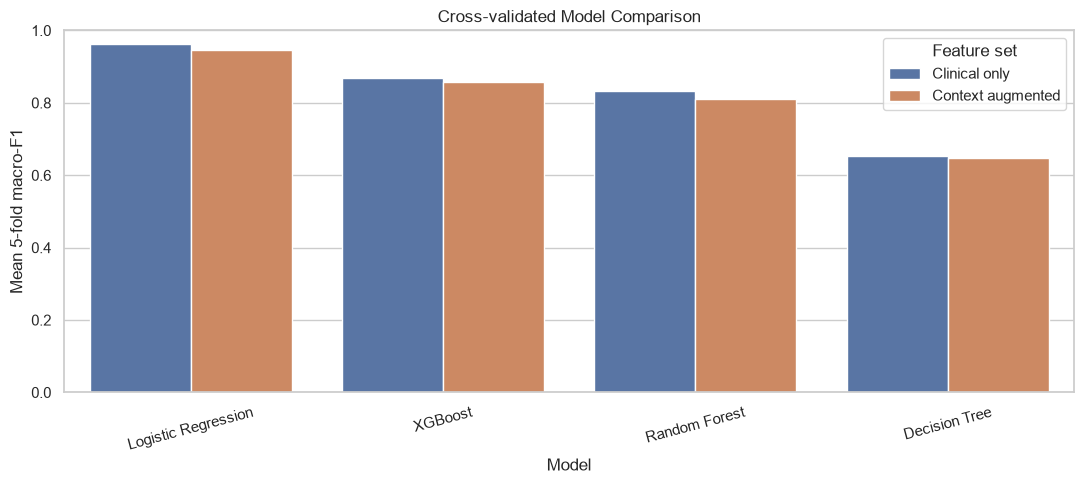

In [7]:
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison, x="Model", y="f1_macro mean", hue="Feature set")
plt.ylim(0, 1)
plt.ylabel("Mean 5-fold macro-F1")
plt.title("Cross-validated Model Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 6. Tune the strongest training-stage candidate

The winning candidate is selected only from cross-validation on the training partition. Its hyperparameters are then tuned with another stratified training-only search.

In [8]:
winner_row = comparison.iloc[0]
winner_feature_set = winner_row["Feature set"]
winner_model_name = winner_row["Model"]
winner_features = (feature_sets[winner_feature_set]["numeric"]
                   + feature_sets[winner_feature_set]["categorical"])
winner_pipeline = clone(pipelines[(winner_feature_set, winner_model_name)])

parameter_spaces = {
    "Logistic Regression": {
        "model__C": np.logspace(-2, 2, 20),
    },
    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 4, 5, 6, 8, 10, None],
        "model__min_samples_leaf": [1, 2, 3, 5, 8, 12],
        "model__min_samples_split": [2, 5, 10, 20],
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 450, 600],
        "model__max_depth": [None, 6, 8, 10, 14],
        "model__min_samples_leaf": [1, 2, 3, 5],
        "model__max_features": ["sqrt", "log2", 0.7],
    },
    "XGBoost": {
        "model__n_estimators": [150, 250, 350, 500],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.02, 0.04, 0.06, 0.1],
        "model__subsample": [0.75, 0.85, 1.0],
        "model__colsample_bytree": [0.75, 0.85, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    },
}

search = RandomizedSearchCV(
    estimator=winner_pipeline,
    param_distributions=parameter_spaces[winner_model_name],
    n_iter=16, scoring="f1_macro", cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0,
)
search.fit(X_train_all[winner_features], y_train)
best_pipeline = search.best_estimator_

print(f"Selected feature set: {winner_feature_set}")
print(f"Selected algorithm: {winner_model_name}")
print(f"Best training CV macro-F1: {search.best_score_:.3f}")
print("Best hyperparameters:")
display(pd.Series(search.best_params_, name="value").to_frame())

Selected feature set: Clinical only
Selected algorithm: Logistic Regression
Best training CV macro-F1: 0.988
Best hyperparameters:


,value
model__C,100.0


# 7. Final evaluation on the untouched test set

This is the first point at which the final test labels are used for performance assessment.


In [9]:
X_test = X_test_all[winner_features]
test_predictions = best_pipeline.predict(X_test)
test_probabilities = best_pipeline.predict_proba(X_test)

test_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Balanced accuracy": balanced_accuracy_score(y_test, test_predictions),
    "Macro precision": precision_score(y_test, test_predictions, average="macro", zero_division=0),
    "Macro recall": recall_score(y_test, test_predictions, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, test_predictions, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, test_predictions, average="weighted", zero_division=0),
    "Macro ROC-AUC (OvR)": roc_auc_score(y_test, test_probabilities, multi_class="ovr", average="macro"),
    "Quadratic weighted kappa": cohen_kappa_score(y_test, test_predictions, weights="quadratic"),
    "Ordinal MAE": mean_absolute_error(y_test, test_predictions),
    "Severe Low-High error rate": np.mean(np.abs(y_test.to_numpy() - test_predictions) == 2),
})
display(test_metrics.round(3).to_frame("Test value"))

report = pd.DataFrame(classification_report(
    y_test, test_predictions, labels=[0, 1, 2], target_names=CLASS_NAMES,
    output_dict=True, zero_division=0,
)).T
display(report.round(3))

,Test value
Accuracy,0.995
Balanced accuracy,0.996
Macro precision,0.988
Macro recall,0.996
Macro F1,0.992
Weighted F1,0.995
Macro ROC-AUC (OvR),1.000
Quadratic weighted kappa,0.995
Ordinal MAE,0.005
Severe Low-High error rate,0.000


,precision,recall,f1-score,support
Low,0.963,1.000,0.981,26.000
Medium,1.000,0.989,0.995,94.000
High,1.000,1.000,1.000,80.000
accuracy,0.995,0.995,0.995,0.995
macro avg,0.988,0.996,0.992,200.000
weighted avg,0.995,0.995,0.995,200.000


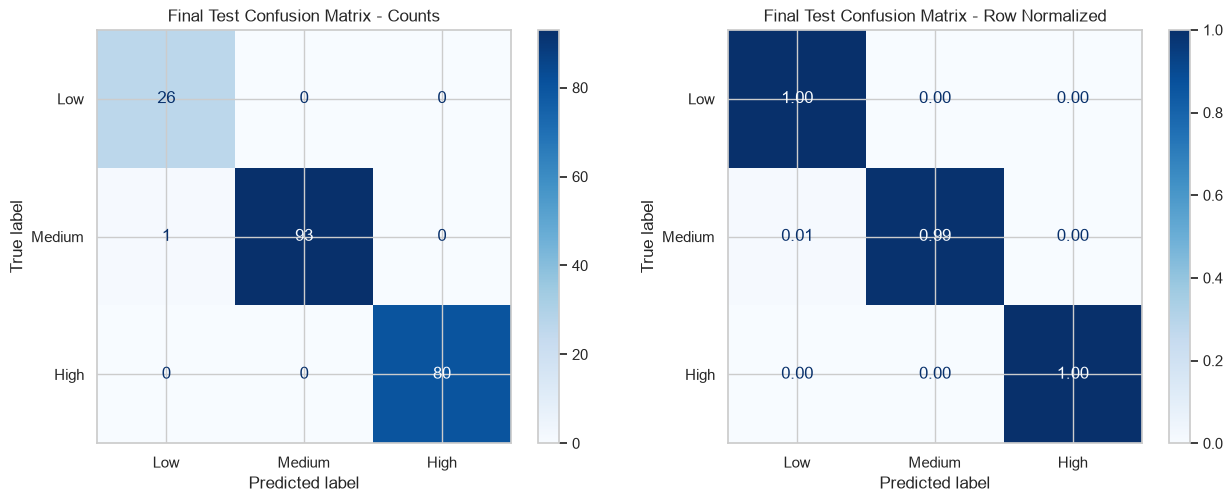

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=CLASS_NAMES, cmap="Blues", ax=axes[0]
)
axes[0].set_title("Final Test Confusion Matrix - Counts")
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=CLASS_NAMES, cmap="Blues",
    normalize="true", values_format=".2f", ax=axes[1]
)
axes[1].set_title("Final Test Confusion Matrix - Row Normalized")
plt.tight_layout()
plt.show()

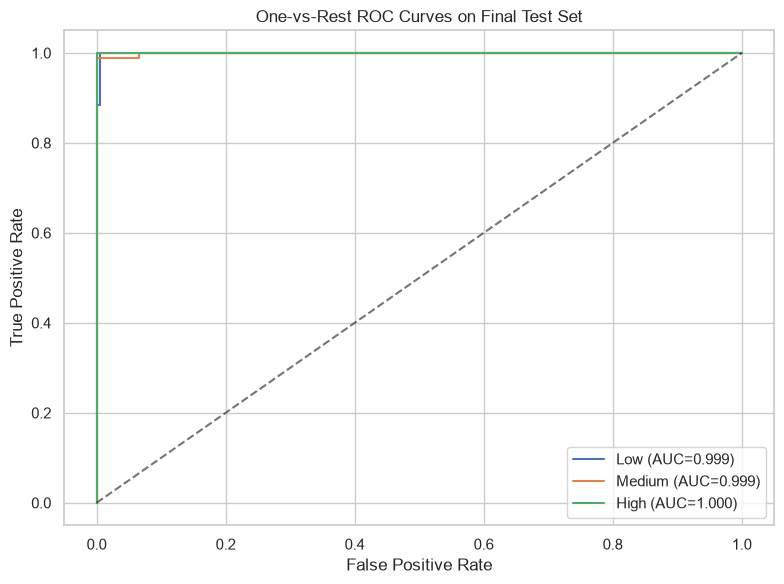

In [11]:
y_test_binary = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(8, 6))
for class_index, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_binary[:, class_index], test_probabilities[:, class_index])
    auc_value = roc_auc_score(y_test_binary[:, class_index], test_probabilities[:, class_index])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves on Final Test Set")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Model-agnostic feature importance

Permutation importance measures how much test macro-F1 decreases when each original input feature is shuffled. It describes model reliance and does not establish medical causation.

,feature,importance_mean,importance_std
4,blood_sugar_mg_dl,0.3472,0.0323
5,cholesterol_mg_dl,0.3135,0.0370
0,age,0.2979,0.0243
6,bmi,0.2827,0.0276
1,previous_admissions,0.1878,0.0201
2,systolic_bp,0.0786,0.0175
8,mean_arterial_pressure,0.0568,0.0168
7,pulse_pressure,0.0540,0.0152
9,has_previous_admission,0.0096,0.0055
10,gender,0.0019,0.0019


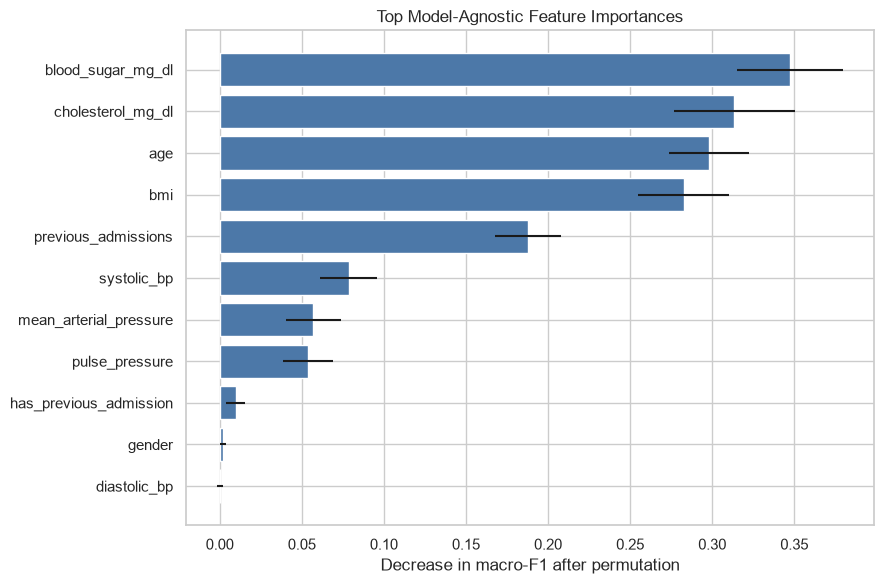

In [12]:
importance_result = permutation_importance(
    best_pipeline, X_test, y_test, scoring="f1_macro",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=1,
)
importance_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("importance_mean", ascending=False)
display(importance_table.round(4))

plot_data = importance_table.head(15).sort_values("importance_mean")
plt.figure(figsize=(9, 6))
plt.barh(plot_data["feature"], plot_data["importance_mean"],
         xerr=plot_data["importance_std"], color="#4c78a8")
plt.xlabel("Decrease in macro-F1 after permutation")
plt.title("Top Model-Agnostic Feature Importances")
plt.tight_layout()
plt.show()

# 9. Inspect example patient predictions and uncertainty


In [13]:
prediction_examples = X_test.reset_index(drop=True).copy()
prediction_examples["actual_risk"] = y_test.map(INT_TO_CLASS).reset_index(drop=True)
prediction_examples["predicted_risk"] = pd.Series(test_predictions).map(INT_TO_CLASS)
for class_index, class_name in enumerate(CLASS_NAMES):
    prediction_examples[f"probability_{class_name.lower()}"] = test_probabilities[:, class_index]
prediction_examples["confidence"] = test_probabilities.max(axis=1)
prediction_examples["correct"] = (
    prediction_examples["actual_risk"] == prediction_examples["predicted_risk"]
)
display(prediction_examples.sort_values(["correct", "confidence"]).head(12).round(3))

,age,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,pulse_pressure,mean_arterial_pressure,has_previous_admission,gender,actual_risk,predicted_risk,probability_low,probability_medium,probability_high,confidence,correct
134,18,3,106,83,106,149,25.4,23,90.667,1,Female,Medium,Low,0.851,0.149,0.000,0.851,False
61,7,1,134,93,94,213,23.6,41,106.667,1,Male,Low,Low,0.554,0.446,0.000,0.554,True
154,32,0,136,68,130,196,30.7,68,90.667,0,Male,Medium,Medium,0.000,0.578,0.422,0.578,True
70,32,0,126,80,98,217,20.7,46,95.333,0,Female,Low,Low,0.687,0.313,0.000,0.687,True
173,52,0,127,78,140,219,22.2,49,94.333,0,Female,Medium,Medium,0.000,0.737,0.263,0.737,True
191,50,0,117,76,130,193,29.1,41,89.667,0,Female,Medium,Medium,0.000,0.759,0.241,0.759,True
113,57,0,152,78,99,188,28.7,74,102.667,0,Male,Medium,Medium,0.000,0.786,0.214,0.786,True
160,37,0,119,59,144,119,24.1,60,79.000,0,Female,Low,Low,0.806,0.194,0.000,0.806,True
83,58,0,145,75,99,227,25.6,70,98.333,0,Male,High,High,0.000,0.193,0.807,0.807,True
159,50,0,123,73,117,217,28.5,50,89.667,0,Female,High,High,0.000,0.182,0.818,0.818,True


# 10. Save the complete trained pipeline and metadata

In [14]:
MODEL_PATH = MODEL_DIR / "smartcare_option_c_best_pipeline.joblib"
METADATA_PATH = MODEL_DIR / "smartcare_option_c_metadata.json"

joblib.dump(best_pipeline, MODEL_PATH)
metadata = {
    "target": TARGET,
    "class_names": CLASS_NAMES,
    "feature_set": winner_feature_set,
    "algorithm": winner_model_name,
    "features": winner_features,
    "random_state": RANDOM_STATE,
    "training_rows": int(len(y_train)),
    "test_rows": int(len(y_test)),
    "best_cv_macro_f1": float(search.best_score_),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "best_hyperparameters": search.best_params_,
    "warning": "Educational prototype trained on synthetic data; not clinically validated.",
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

loaded_pipeline = joblib.load(MODEL_PATH)
assert np.array_equal(loaded_pipeline.predict(X_test.head(10)), test_predictions[:10])
print(f"Saved and reloaded successfully: {MODEL_PATH}")
print(f"Saved metadata: {METADATA_PATH}")

Saved and reloaded successfully: D:\AI Final\models\smartcare_option_c_best_pipeline.joblib
Saved metadata: D:\AI Final\models\smartcare_option_c_metadata.json


#Stage-two conclusion

The model-selection result must be interpreted from the displayed cross-validation and final-test tables. Macro-F1 is the primary selection metric because it gives Low, Medium and High risk equal importance. The confusion matrix and ordinal metrics reveal whether errors are mostly adjacent or include dangerous Low-to-High reversals. The next stage is SHAP-based global and patient-level explainability, subgroup error auditing, and integration of the saved pipeline into a Streamlit prototype.